# Laboratorio: Redes Neuronales Convolucionales
## Dataset: Fashion-MNIST
**Objetivo:** Comparar un modelo baseline (sin convoluciones) contra una CNN 
diseñada desde cero, y explorar el efecto de distintas decisiones arquitectónicas.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Librerias listas.")

TensorFlow: 2.21.0
NumPy: 2.4.6
Librerias listas.


In [19]:
# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(" Forma de los datos ")
print(f"  Entrenamiento : {x_train.shape}")
print(f"  Prueba        : {x_test.shape}")
print(f"  Tipo de dato  : {x_train.dtype}")
print(f"  Rango valores : {x_train.min()} – {x_train.max()}")

 Forma de los datos 
  Entrenamiento : (60000, 28, 28)
  Prueba        : (10000, 28, 28)
  Tipo de dato  : uint8
  Rango valores : 0 – 255


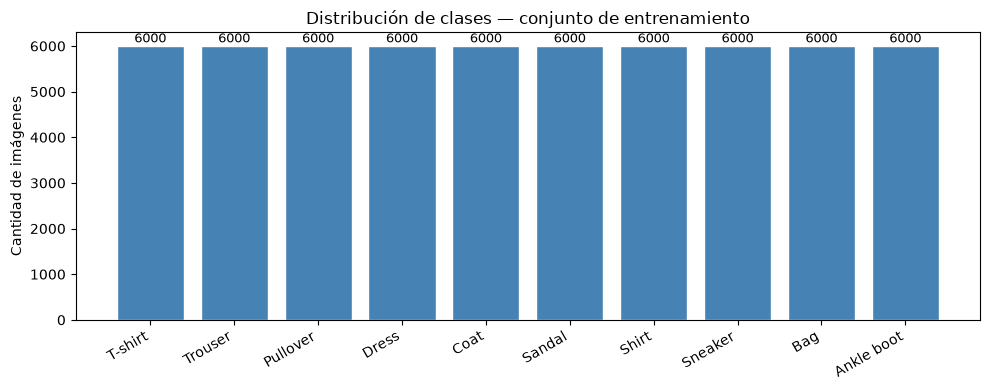

In [20]:
# Distribución de clases
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, counts, color='steelblue', edgecolor='white')
plt.title('Distribución de clases — conjunto de entrenamiento')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

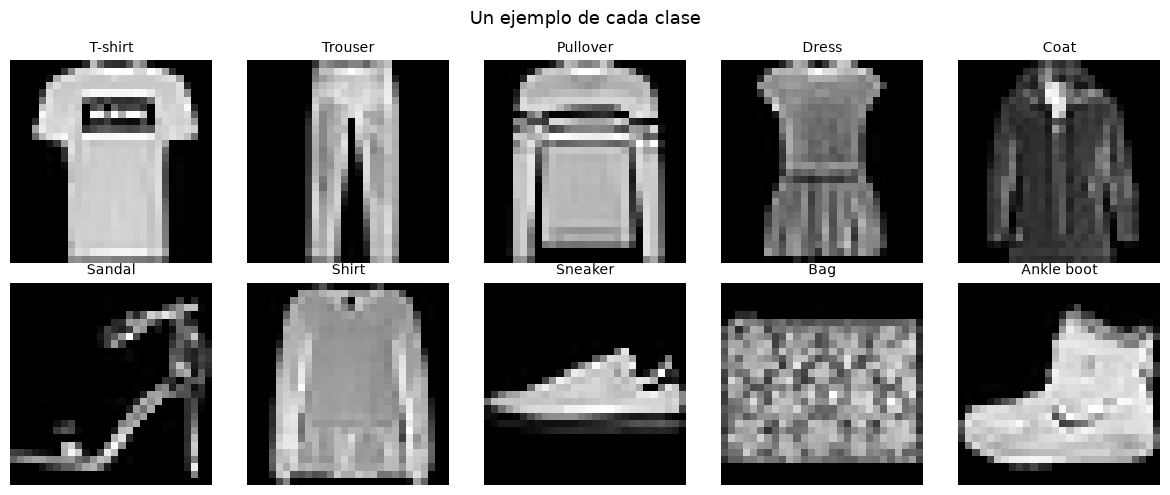

In [21]:
# Visualizar ejemplos por clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(x_train[idx], cmap='gray')
    axes[i].set_title(class_names[i], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Un ejemplo de cada clase', fontsize=13)
plt.tight_layout()
plt.show()

## Observaciones del EDA

- **Tamaño:** 70,000 imágenes en total (60,000 train / 10,000 test)
- **Dimensiones:** 28×28 píxeles, escala de grises (1 canal)
- **Clases:** 10, perfectamente balanceadas (6,000 por clase)
- **Rango de valores:** 0–255 → se normalizará a 0–1
- **Justificación para CNN:** Las imágenes tienen estructura espacial local 
  (bordes de prendas, texturas, siluetas) que las capas convolucionales 
  pueden capturar mediante filtros. Una red completamente conectada ignoraría 
  esta estructura espacial.

In [22]:
# Normalización y preparación
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Para la CNN añadimos dimensión de canal: (28,28) → (28,28,1)
x_train_cnn = x_train_norm[..., np.newaxis]
x_test_cnn  = x_test_norm[..., np.newaxis]

print(f"Datos para baseline : {x_train_norm.shape}  rango [{x_train_norm.min():.1f} – {x_train_norm.max():.1f}]")
print(f"Datos para CNN      : {x_train_cnn.shape}  rango [{x_train_cnn.min():.1f} – {x_train_cnn.max():.1f}]")
print("Preprocesamiento completo.")

Datos para baseline : (60000, 28, 28)  rango [0.0 – 1.0]
Datos para CNN      : (60000, 28, 28, 1)  rango [0.0 – 1.0]
Preprocesamiento completo.


## Paso 2: Modelo Baseline (sin convoluciones)

Un modelo completamente conectado (Flatten + Dense) sirve como punto de comparación.
Este modelo no aprovecha la estructura espacial de las imágenes — trata cada píxel
como una variable independiente, ignorando que los píxeles vecinos están relacionados.

In [23]:
# Modelo baseline: Flatten + Dense
baseline = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
], name="baseline")

baseline.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compilar y entrenar baseline
baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8151 - loss: 0.5250 - val_accuracy: 0.8415 - val_loss: 0.4402
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8648 - loss: 0.3722 - val_accuracy: 0.8720 - val_loss: 0.3488
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8780 - loss: 0.3334 - val_accuracy: 0.8712 - val_loss: 0.3517
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8864 - loss: 0.3084 - val_accuracy: 0.8788 - val_loss: 0.3306
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8940 - loss: 0.2908 - val_accuracy: 0.8808 - val_loss: 0.3197
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8983 - loss: 0.2728 - val_accuracy: 0.8828 - val_loss: 0.3087
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9031 - loss: 0.2621 - val_accuracy: 0.8863 - val_loss: 0.3161
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9065 - loss: 0.2489 - val_accuracy: 0.

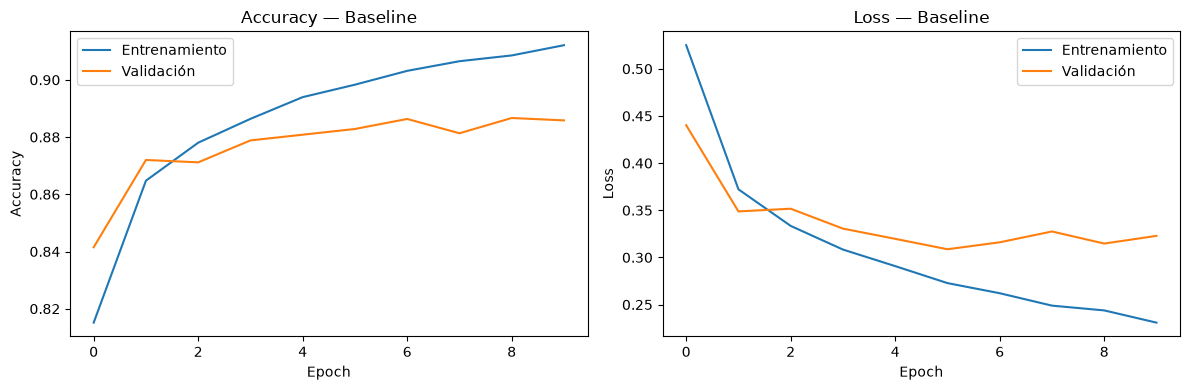


Baseline — Accuracy en test: 0.8810 (88.10%)
Baseline — Loss en test:     0.3393


In [25]:
# Curvas de entrenamiento del baseline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_baseline.history['accuracy'], label='Entrenamiento')
ax1.plot(history_baseline.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy — Baseline')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_baseline.history['loss'], label='Entrenamiento')
ax2.plot(history_baseline.history['val_loss'], label='Validación')
ax2.set_title('Loss — Baseline')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# Evaluación final en test
test_loss, test_acc = baseline.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nBaseline — Accuracy en test: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Baseline — Loss en test:     {test_loss:.4f}")

## Paso 3: Arquitectura CNN

**Decisiones de diseño:**
- 2 capas convolucionales: suficiente para patrones simples en 28×28
- Kernel 3×3: captura bordes y texturas locales sin ser costoso
- Padding 'same': mantiene las dimensiones espaciales
- MaxPooling 2×2: reduce dimensiones a la mitad, conserva features dominantes
- Activación ReLU: introduce no-linealidad, evita el problema del gradiente que desaparece
- Capa Dense final de 64 neuronas antes del clasificador
- 10 salidas con softmax: una probabilidad por clase

In [26]:
# Arquitectura CNN
cnn = keras.Sequential([
    # Bloque 1
    keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu',
                        padding='same', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Bloque 2
    keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu',
                        padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Clasificador
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
], name="cnn")

cnn.summary()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Compilar y entrenar CNN
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn.fit(
    x_train_cnn, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8135 - loss: 0.5274 - val_accuracy: 0.8693 - val_loss: 0.3643
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8818 - loss: 0.3311 - val_accuracy: 0.8872 - val_loss: 0.3106
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8976 - loss: 0.2883 - val_accuracy: 0.9055 - val_loss: 0.2742
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9078 - loss: 0.2573 - val_accuracy: 0.9022 - val_loss: 0.2683
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9146 - loss: 0.2376 - val_accuracy: 0.9058 - val_loss: 0.2593
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9234 - loss: 0.2148 - val_accuracy: 0.9078 - val_loss: 0.2636
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9273 - loss: 0.2019 - val_accuracy: 0.9153 - val_loss: 0.2364
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9340 - loss: 0.1822 - val_accu

CNN      — Accuracy en test: 0.9148 (91.48%)
Baseline — Accuracy en test: 0.8810 (88.10%)

Mejora: +3.38 puntos porcentuales


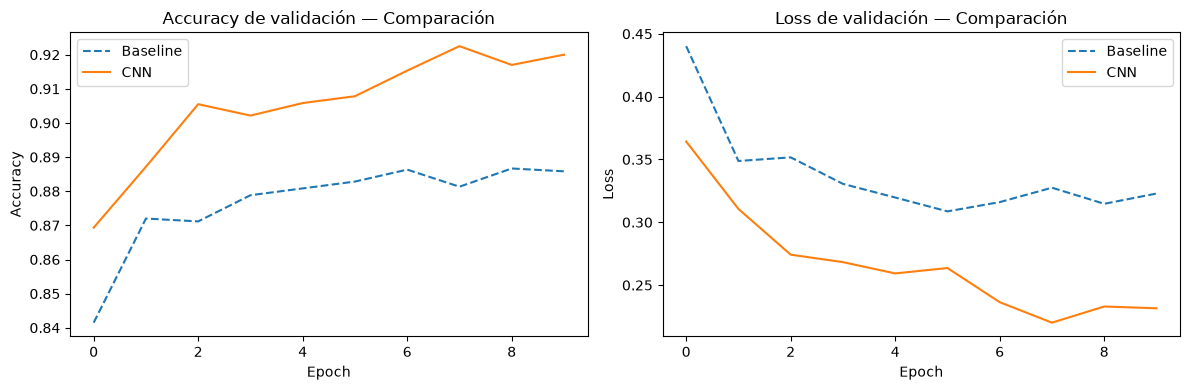

In [28]:
# Evaluación final CNN en test
test_loss_cnn, test_acc_cnn = cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f"CNN      — Accuracy en test: {test_acc_cnn:.4f} ({test_acc_cnn*100:.2f}%)")
print(f"Baseline — Accuracy en test: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nMejora: +{(test_acc_cnn - test_acc)*100:.2f} puntos porcentuales")

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline', linestyle='--')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN')
axes[0].set_title('Accuracy de validación — Comparación')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_baseline.history['val_loss'], label='Baseline', linestyle='--')
axes[1].plot(history_cnn.history['val_loss'], label='CNN')
axes[1].set_title('Loss de validación — Comparación')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()